# Estudio Comparativo: Navegación de Flappy Bird mediante LiDAR

En este experimento evolucionamos el clásico problema de control visual (basado en píxeles) hacia un enfoque de **robótica sensorial** utilizando telemetría LiDAR (Light Detection and Ranging). Utilizaremos el entorno `flappy-bird-gymnasium`.

Compararemos la eficacia de dos métodos de aprendizaje profundo por refuerzo operando sobre este nuevo espacio vectorial:
1. **DQN (Deep Q-Network)**: *Off-policy* con Replay Buffer.
2. **SARSA Semi-gradiente**: *On-policy* con aproximación de función lineal.

## Análisis de Contribución y Alineación Científica

La mayoría de implementaciones clásicas de Flappy Bird (como *Mnih et al., 2015*) utilizan **CNNs (Redes Convolucionales)** procesando imágenes crudas ($84 \times 84 \times 4 \approx 28,224$ inputs). Este enfoque es computacionalmente costoso y suele requerir un preprocesamiento complejo (escala de grises, recorte, apilado de frames).

Basándonos en la literatura reciente (*"Flappy Bird RL Performance using LiDAR", MDPI Sensors 2024*), proponemos las siguientes contribuciones de estudio:

1.  **Reducción de Dimensionalidad (The Curse of Dimensionality)**:
    Sustituimos la visión artificial por un **sensor LiDAR**. Esto reduce el espacio de estado de miles de píxeles a un vector de **180 distancias escalares** (rayos láser simulados). Esto permite usar redes **MLP (Perceptrones Multicapa)** simples para DQN y un aproximador lineal para SARSA, reduciendo drásticamente el número de parámetros y el tiempo de cómputo por paso.

2.  **Aceleración de Convergencia**:
    Al eliminar la necesidad de que la red "aprenda a ver" (extracción de características visuales de los bordes de las tuberías), el agente puede centrarse inmediatamente en aprender la **dinámica cinemática** y la relación distancia-acción.

3.  **Abstracción y Generalización**:
    Un agente basado en LiDAR es invariante a cambios estéticos (color de fondo, texturas, skins del pájaro) que confundirían a una CNN entrenada visualmente. Esto se acerca más a la navegación de robots móviles reales.

### Referencias
- Entorno: [flappy-bird-gymnasium](https://github.com/markub3327/flappy-bird-gymnasium)
- Artículo base: [MDPI Sensors 2024](https://www.mdpi.com/1424-8220/24/6/1905)

In [1]:
# Instalación del entorno específico con soporte LiDAR
# Descomentar si no está instalado:
# !pip install flappy-bird-gymnasium gymnasium torch matplotlib imageio imageio[ffmpeg] tqdm

import os
import gc
import gymnasium as gym
import flappy_bird_gymnasium
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
import collections
import matplotlib.pyplot as plt
from collections import deque
import imageio
# from tqdm.notebook import tqdm  # Dependencia externa ipywidgets propensa a fallos
from tqdm import tqdm # Usamos la versión estándar de texto que es más robusta

# --- 5.4. Recomendación para Semillas Fijas (Profesor) ---
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cpu") 
# OPTIMIZACIÓN: Restringir PyTorch a un solo hilo para evitar overhead en redes MLP pequeñas
torch.set_num_threads(1)
print(f"Usando dispositivo: {device}")

# Liberación de memoria
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Configuración de variables de entorno para determinismo en CUDA (Opcional, puede impactar rendimiento)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Configuración de la semilla para reproducibilidad
SEED = 2024
N_EPISODES = 2000
# Fijar la semilla en NumPy
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Fijar la semilla en Python (hash)
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

# Fijar la semilla en PyTorch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Semilla global establecida: {SEED}")

Usando dispositivo: cpu
Semilla global establecida: 2024


## 1. Configuración del Entorno LiDAR

A diferencia del enfoque visual, aquí no necesitamos `FrameStack` (memoria de inercia visual) ni conversión a escala de grises. El entorno `FlappyBird-v0` con la opción `use_lidar=True` nos devuelve directamente un **vector 1D** que representa las distancias a los obstáculos (suelo, techo, tuberías) en un abanico radial alrededor del pájaro.

In [2]:
def make_env(render_mode=None, seed=None):
    # use_lidar=True activa el sensor de distancia en lugar de la imagen RGB
    env = gym.make("FlappyBird-v0", render_mode=render_mode, use_lidar=True)
    
    # Aplicar semilla al reset inicial según recomendación
    if seed is not None:
        env.reset(seed=seed)
    
    return env

# Inspección del Espacio de Observación
temp_env = make_env(seed=SEED)
obs_dim = temp_env.observation_space.shape[0]
action_dim = temp_env.action_space.n
print(f"Espacio de Observación: {temp_env.observation_space}")
print(f"Espacio de Acción: {temp_env.action_space}")
print(f"Dimensión del Sensor LiDAR: {obs_dim} rayos (Inputs)")
temp_env.close()

Espacio de Observación: Box(0.0, 1.0, (180,), float64)
Espacio de Acción: Discrete(2)
Dimensión del Sensor LiDAR: 180 rayos (Inputs)


c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [3]:
from collections import defaultdict, deque
class Agent:
    """Esquema general de un agente"""
    def __init__(self, env:gym.Env, **kwargs):
        """Inicializa todo lo necesario para el aprendizaje"""
        self.env = env
        
    def get_action(self, state):
        """Indicará qué acción realizar de acuerdo al estado."""
        raise NotImplementedError
        
    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        """Aplicamos el algoritmo de aprendizaje."""
        raise NotImplementedError
# --- DEFINICIÓN DE AGENTE TABULAR N-PASOS ---
class TabularNStepAgent(Agent):
    def __init__(self, num_rays, action_dim, n_steps=1, gamma=0.99, lr=0.1, off_policy=False, epsilon_start=1.0, epsilon_decay=0.9995):
        self.num_rays = num_rays
        self.action_dim = action_dim
        self.n_steps = n_steps
        self.gamma = gamma
        self.lr = lr
        self.off_policy = off_policy # False=SARSA (On-policy), True=Q-Learning (Off-policy/TreeBackup naive)
        self.epsilon = epsilon_start
        self.epsilon_min = 0.01
        self.epsilon_decay = epsilon_decay
        
        # 2^10 = 1024 estados. Usamos defaultdict para no inicializar todo si no se visita
        self.q_table = defaultdict(lambda: np.zeros(action_dim))
        
        # Buffer para N-pasos: guardará tuplas (obs, action, reward)
        self.buffer = deque(maxlen=n_steps + 1)
        
        # Índices para reducir 180 rayos a 10 (equiespaciados)
        self.ray_indices = np.linspace(0, 179, num_rays, dtype=int)
        self.threshold = 0.5 # Umbral para "Cerca/Lejos"
        
    def discretize(self, obs):
        """Convierte vector lidar en índice entero usando máscara de bits (10 bits)"""
        # Seleccionamos solo los rayos de interés
        selected_obs = obs[self.ray_indices]
        state_idx = 0
        for i, val in enumerate(selected_obs):
            if val < self.threshold: # Obstáculo detectado cerca (Bit = 1)
                state_idx += (1 << i)
        return state_idx

    def get_action(self, obs, evaluate=False):
        state_idx = self.discretize(obs)
        if not evaluate and random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        return int(np.argmax(self.q_table[state_idx]))
    
    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        done = terminated or truncated
        # Añadimos la transición actual al buffer
        self.buffer.append((obs, action, reward))
        
        # Si el buffer está lleno o el episodio ha terminado, realizamos actualizaciones
        while (len(self.buffer) > 0 and done) or (len(self.buffer) >= self.n_steps):
             if len(self.buffer) == 0: break

             # Elemento más antiguo a actualizar (S_tau, A_tau)
             s_tau, a_tau, _ = self.buffer[0]
             
             # Calculamos el Retorno G acumulado en el buffer
             G = 0
             discount = 1.0
             for k in range(len(self.buffer)):
                 # r_k es la recompensa del paso k en el buffer
                 # buffer[k][2] es la reward almacenada
                 G += discount * self.buffer[k][2]
                 discount *= self.gamma
                 
             # Bootstrapping (si no ha terminado el episodio)
             # Si done=True, todo lo que queda en el buffer es terminal respecto al final del episodio,
             # por lo que no añadimos valor estimado futuro (G es el retorno real truncado).
             # Si done=False, significa que el buffer está lleno (len=n) y miramos 'next_obs'
             if not done:
                 if self.off_policy:
                     # Off-Policy (Q-Learning): Bootstrap con max_a Q(S_{t+1})
                     state_next_idx = self.discretize(next_obs)
                     bootstrap_val = np.max(self.q_table[state_next_idx])
                 else:
                     # On-Policy (SARSA): Bootstrap con Q(S_{t+1}, A_{t+1})
                     # Nota: En N-step SARSA estricto, deberíamos usar la acción real futura.
                     # Como aproximación online usamos la política actual (get_action).
                     next_action = self.get_action(next_obs) 
                     state_next_idx = self.discretize(next_obs)
                     bootstrap_val = self.q_table[state_next_idx][next_action]
                     
                 G += discount * bootstrap_val
             
             # Q-Learning Update: Q += lr * (Target - Q)
             state_idx = self.discretize(s_tau)
             old_q = self.q_table[state_idx][a_tau]
             self.q_table[state_idx][a_tau] += self.lr * (G - old_q)
             
             # Eliminamos el paso ya procesado
             self.buffer.popleft()
             
             # Si no hemos terminado (done=False), solo procesamos UN paso (el más antiguo) y salimos
             # para esperar al siguiente step del entorno.
             if not done:
                 break
        
        if self.epsilon > self.epsilon_min: self.epsilon *= self.epsilon_decay

# Función de entrenamiento local para este experimento
def train_tabular_experiment(agent_class, n_steps_list, off_policy_modes, episodes=500):
    results = {}
    
    for mode_name, is_off_policy in off_policy_modes.items():
        results[mode_name] = {}
        for n in n_steps_list:
            key = f"{mode_name}_n{n}"
            print(f"Entrenando {key} ...")
            
            # Instanciamos agente (10 rayos fijo)
            agent = agent_class(num_rays=10, action_dim=2, n_steps=n, 
                                gamma=0.99, lr=0.1, off_policy=is_off_policy)
            
            scores = []
            flight_times = []
            env = make_env(seed=SEED) # Usamos semilla fija base para comparar
            
            for ep in tqdm(range(episodes), desc=f"{key}"):
                obs, _ = env.reset(seed=SEED+ep) # Variamos semilla por episodio
                done = False
                score = 0
                steps = 0
                while not done:
                    action = agent.get_action(obs)
                    steps += 1
                    next_obs, reward, terminated, truncated, _ = env.step(action)
                    agent.update(obs, action, next_obs, reward, terminated, truncated, {})
                    done = terminated or truncated
                    obs = next_obs
                    score += reward
                scores.append(score)
                flight_times.append(steps)  # Suponiendo que el score representa el tiempo de vuelo
            
            # Guardamos medias móviles para limpiar gráfico
            results[mode_name][n] = {'scores': scores, 'flight_times': flight_times}
            env.close()
            
    return results

# EJECUCIÓN DEL EXPERIMENTO 0
n_steps_to_test = [1, 5, 10, 20]
modes = {
    "On-Policy (SARSA)": False,
    "Off-Policy (Q-Learning)": True
}

print("=== INICIANDO EXPERIMENTO 0: BASELINE TABULAR N-PASOS ===")
tabular_results = train_tabular_experiment(TabularNStepAgent, n_steps_to_test, modes, episodes=N_EPISODES*2)


=== INICIANDO EXPERIMENTO 0: BASELINE TABULAR N-PASOS ===
Entrenando On-Policy (SARSA)_n1 ...


On-Policy (SARSA)_n1:   0%|          | 0/4000 [00:00<?, ?it/s]c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
On-Policy (SARSA)_n1: 100%|██████████| 4000/4000 [05:19<00:00, 12.53it/s]


Entrenando On-Policy (SARSA)_n5 ...


On-Policy (SARSA)_n5: 100%|██████████| 4000/4000 [05:38<00:00, 11.81it/s]


Entrenando On-Policy (SARSA)_n10 ...


...

Off-Policy (Q-Learning)_n5: 100%|██████████| 4000/4000 [05:47<00:00, 11.51it/s]


Entrenando Off-Policy (Q-Learning)_n10 ...


Off-Policy (Q-Learning)_n10: 100%|██████████| 4000/4000 [06:17<00:00, 10.61it/s]


Entrenando Off-Policy (Q-Learning)_n20 ...


Off-Policy (Q-Learning)_n20: 100%|██████████| 4000/4000 [06:06<00:00, 10.90it/s]


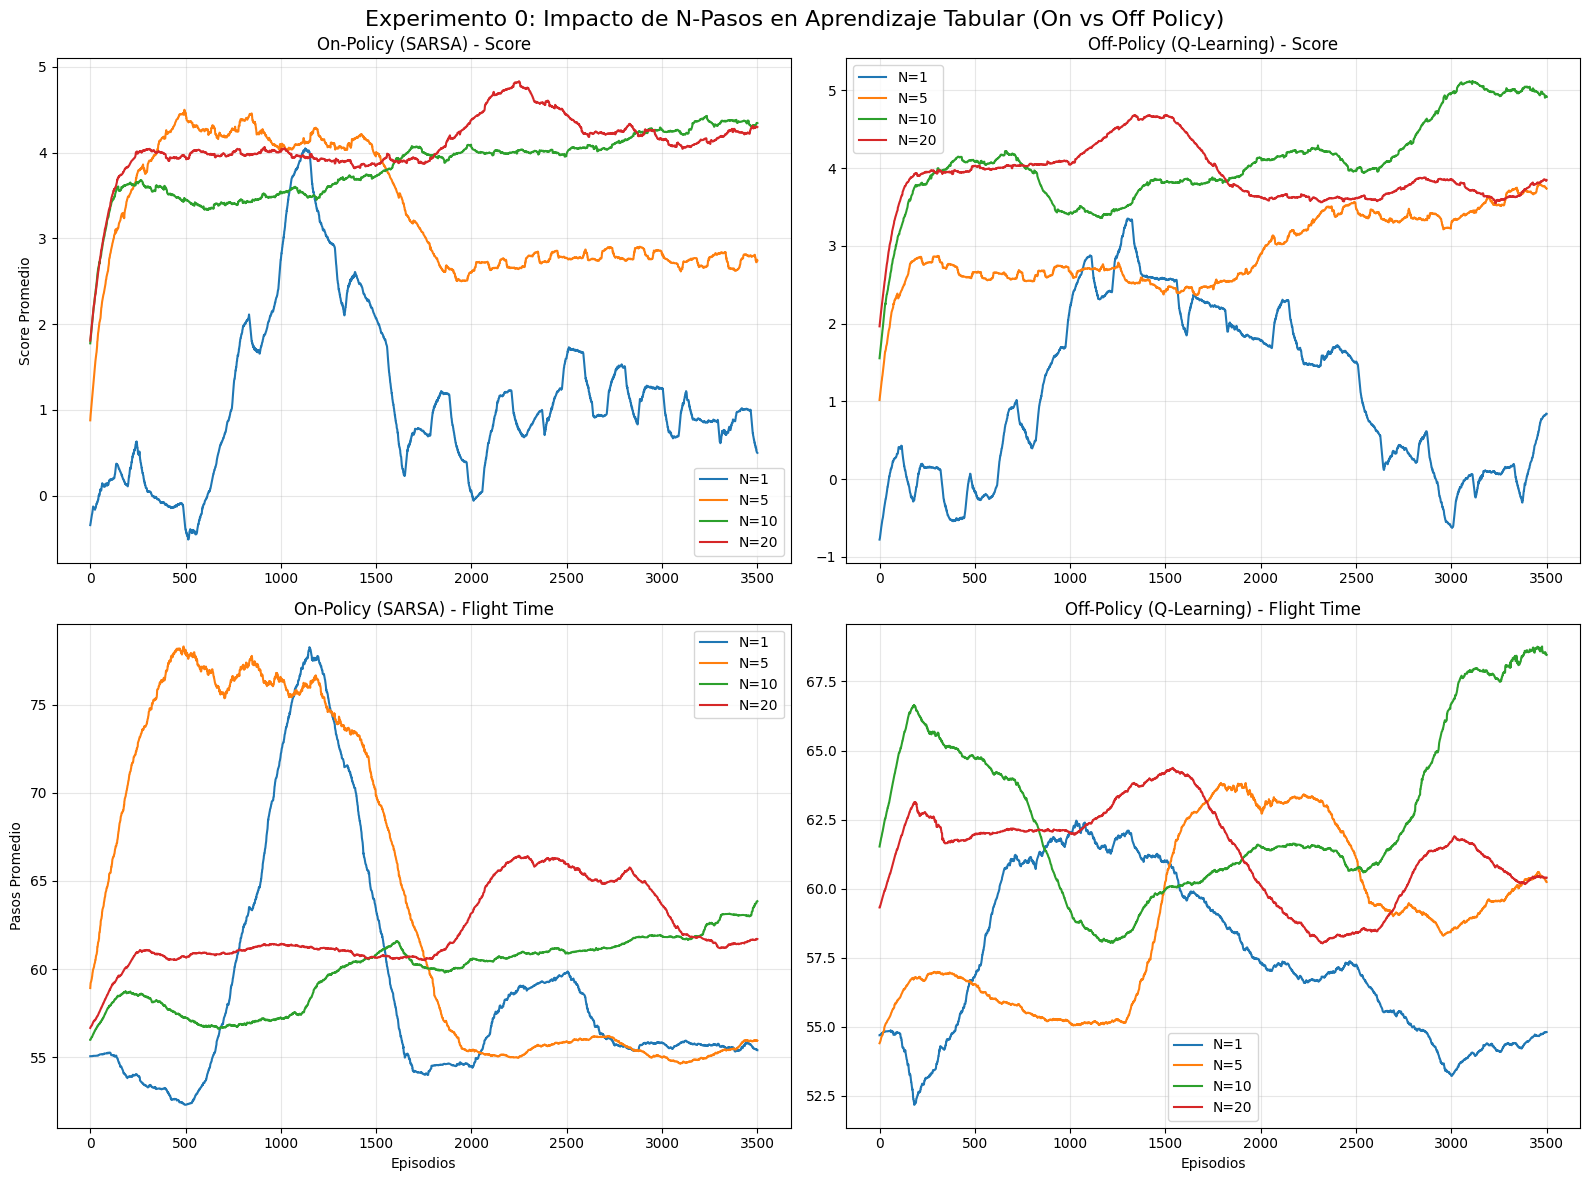

In [4]:

# Visualización
# Ahora necesitamos 2 filas (Score y Tiempo de Vuelo) y 2 columnas (On-Policy y Off-Policy)
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Experimento 0: Impacto de N-Pasos en Aprendizaje Tabular (On vs Off Policy)', fontsize=16)

def smooth(data, k=500):
    if len(data) < k: return data
    return np.convolve(data, np.ones(k)/k, mode='valid')

# Fila 1: Puntuación (Score)
# Col 1: On-Policy
ax = axs[0, 0]
for n, metrics in tabular_results["On-Policy (SARSA)"].items():
    ax.plot(smooth(metrics['scores'], k=500), label=f'N={n}')
ax.set_title('On-Policy (SARSA) - Score')
ax.set_ylabel('Score Promedio')
ax.legend()
ax.grid(True, alpha=0.3)

# Col 2: Off-Policy
ax = axs[0, 1]
for n, metrics in tabular_results["Off-Policy (Q-Learning)"].items():
    ax.plot(smooth(metrics['scores'], k=500), label=f'N={n}')
ax.set_title('Off-Policy (Q-Learning) - Score')
ax.legend()
ax.grid(True, alpha=0.3)

# Fila 2: Tiempo de Vuelo (Steps)
# Col 1: On-Policy
ax = axs[1, 0]
for n, metrics in tabular_results["On-Policy (SARSA)"].items():
    ax.plot(smooth(metrics['flight_times'], k=500), label=f'N={n}')
ax.set_title('On-Policy (SARSA) - Flight Time')
ax.set_ylabel('Pasos Promedio')
ax.set_xlabel('Episodios')
ax.legend()
ax.grid(True, alpha=0.3)

# Col 2: Off-Policy
ax = axs[1, 1]
for n, metrics in tabular_results["Off-Policy (Q-Learning)"].items():
    ax.plot(smooth(metrics['flight_times']), label=f'N={n}')
ax.set_title('Off-Policy (Q-Learning) - Flight Time')
ax.set_xlabel('Episodios')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Justificación Teórica: ¿Por qué NO usar métodos Tabulares?

Al activar el sensor LiDAR, transformamos la observación en un vector de **180 valores continuos** (números flotantes que representan distancias).

### Análisis de la Maldición de la Dimensionalidad
Un método tabular (como Q-Learning estándar) requeriría una matriz $Q(s, a)$. Incluso si simplificamos radicalmente el problema discretizando los valores:

1.  Supongamos que discretizamos cada uno de los 180 láseres en solo **2 estados** (cerca/lejos).
    $$ |S| = 2^{180} \approx 1.53 \times 10^{54} \text{ estados combinatorios} $$
    *(Esta magnitud excede por mucho la memoria de cualquier computador existente)*

2.  En realidad, las distancias son valores continuos (`float32`). El espacio de estados es **infinito no numerable** ($\mathbb{R}^{180}$).

### Conclusión
Es **imposible** almacenar o visitar todos los estados en una tabla. Necesitamos obligatoriamente **Aproximación de Funciones** que puedan:
1.  Manejar entradas continuas sin sufrir una explosión combinatoria.
2.  **Generalizar**: Entender que una distancia de `0.51` es cinemáticamente casi idéntica a `0.52`. Un método tabular trataría estos valores como casillas totalmente independientes sin compartir aprendizaje entre ellas.

Por esta razón fundamental, el uso de aproximación de funciones (como **Deep Q-Learning** o **SARSA Semi-gradiente**) no es opcional, sino necesario.

In [5]:
class MaskedEnvWrapper(gym.ObservationWrapper):
    """Wrapper para reducir el número de rayos procesados por el agente"""
    def __init__(self, env, num_rays):
        super().__init__(env)
        self.num_rays = num_rays
        # Calculamos los índices a mantener equiespaciados
        self.keep_indices = np.linspace(0, 179, num_rays, dtype=int)
        
        # Redefinimos el espacio de observación
        old_space = env.observation_space
        self.observation_space = gym.spaces.Box(
            low=old_space.low[0], 
            high=old_space.high[0], 
            shape=(num_rays,), 
            dtype=np.float32
        )

    def observation(self, obs):
        return obs[self.keep_indices]
    
class FrameStackWrapper(gym.ObservationWrapper):
    """
    Acumula las últimas 'k' observaciones del LiDAR.
    Esto permite a la red neuronal deducir la velocidad y dirección (derivadas temporales) de los obstáculos.
    """
    def __init__(self, env, k=3):
        super().__init__(env)
        self.k = k
        self.frames = collections.deque(maxlen=k)
        
        # El nuevo espacio de observación tendrá tamaño (k * dimensión_original)
        old_shape = env.observation_space.shape
        self.obs_dim = old_shape[0]
        
        low = np.repeat(env.observation_space.low, k, axis=0)
        high = np.repeat(env.observation_space.high, k, axis=0)
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        for _ in range(self.k):
            self.frames.append(obs)
        return self._get_ob(), info

    def observation(self, obs):
        self.frames.append(obs)
        return self._get_ob()

    def _get_ob(self):
        # Concatena los k frames guardados en un único vector 1D
        return np.concatenate(self.frames, axis=0)

def make_env_stacked(render_mode=None, seed=None, k=3, num_rays=180):
    env = gym.make("FlappyBird-v0", render_mode=render_mode, use_lidar=True)
    if num_rays < 180:
        env = MaskedEnvWrapper(env, num_rays)
        
    if k > 1:
        env = FrameStackWrapper(env, k)
        
    if seed is not None:
        env.reset(seed=seed)
    return env

## 2. Arquitectura de Red y Función de Valor

Abandonamos las costosas CNNs. Para **DQN** usaremos una red *feedforward* (totalmente conectada) simple (MLP) utilizando PyTorch. 

Para **SARSA Semi-gradiente** no usaremos PyTorch, sino que aplicaremos la definición matemática pura del algoritmo mediante Numpy, estimando la función de valor paramétrica explícitamente como el producto escalar de un vector de pesos y el estado: $\hat{q}(s,a,w) = w^\top x(s)$. Esto nos permite programar la regla de actualización algorítmica y el cálculo de gradientes directamente según el pseudocódigo.

In [6]:
def moving_average(data, window_size=25):
    if len(data) < window_size: return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Definición de la Red Neuronal Profunda DQN siguiendo especificaciones
class DQN_Network(nn.Module):
    """
    Red neuronal para el algoritmo Deep Q-Network (DQN).
    Se compone de capas totalmente conectadas (FC) con activaciones ReLU.
    """
    def __init__(self, num_actions, input_dim, hidden_dim=64, num_layers=3):
        """
        Inicializa la red neuronal.
        Parámetros:
        num_actions (int): Número total de acciones posibles en el entorno.
        input_dim (int): Dimensión del espacio de estados de entrada.
        hidden_dim (int): Nodos en capas ocultas (por defecto 64).
        num_layers (int): Profundidad de la red (por defecto 3).
        """
        super(DQN_Network, self).__init__()
        
        # Construcción dinámica de capas Sequential para soportar experimentación de topologías
        layers = []
        
        # Capa de entrada
        layers.append(nn.Linear(input_dim, hidden_dim if num_layers > 1 else num_actions))
        if num_layers > 1:
            layers.append(nn.ReLU(inplace=True))
            
            # Capas ocultas intermedias
            for _ in range(num_layers - 2):
                layers.append(nn.Linear(hidden_dim, hidden_dim))
                layers.append(nn.ReLU(inplace=True))
            
            # Capa de salida
            layers.append(nn.Linear(hidden_dim, num_actions))
        
        self.FC = nn.Sequential(*layers)
        
        # Inicialización de pesos usando He initialization (Kaiming Uniform)
        # Recorremos los módulos dentro de self.FC
        for module in self.FC:
            if isinstance(module, nn.Linear):
                nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        """
        Propagación hacia adelante de la red para calcular los valores Q.
        Parámetros:
        x (torch.Tensor): Estado de entrada representado como tensor.
        Retorna:
        Q (torch.Tensor): Valores Q para cada acción posible.
        """
        Q = self.FC(x) # Pasa el estado a través de la red neuronal
        return Q

## 3. Implementación de Agentes (DQN vs SARSA Semi-gradiente)

Definimos dos especializaciones para estudiar sus diferencias basándonos en los algoritmos documentados:

- **DQN (Deep Q-learning with Experience Replay)**: Implementado de acuerdo al algoritmo propuesto originalmente en NIPS 2013. Mantiene una *Replay Memory* limitadad de tamaño para romper la correlación temporal.
- **SARSA Semi-gradiente (On-Policy)**: Implementado estrictamente siguiendo el pseudocódigo clásico iterativo. Calcula manualmente la aproximación de valor usando el producto punto $\hat{q}(S,A,w) = w^\top x(s)$ y realiza la actualización paso a paso mediante $w \leftarrow w + \alpha [R + \gamma \hat{q}(S',A',w) - \hat{q}(S,A,w)] \nabla \hat{q}(S,A,w)$.

In [7]:
class Agent:
    """Esquema general de un agente"""
    def __init__(self, env:gym.Env, **kwargs):
        """Inicializa todo lo necesario para el aprendizaje"""
        self.env = env
        
    def get_action(self, state):
        """Indicará qué acción realizar de acuerdo al estado."""
        raise NotImplementedError
        
    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        """Aplicamos el algoritmo de aprendizaje."""
        raise NotImplementedError

class ReplayBuffer:
    """Replay Buffer Optimizado usando Arrays de NumPy pre-asignados"""
    def __init__(self, capacity, state_dim=180):
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity,), dtype=np.int64)
        self.rewards = np.zeros((capacity,), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros((capacity,), dtype=np.float32)
        self.gammas = np.zeros((capacity,), dtype=np.float32)
        
        self.ptr = 0
        self.size = 0
        self.capacity = capacity

    def push(self, state, action, reward, next_state, done, gamma_rate=1.0):
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        self.gammas[self.ptr] = gamma_rate if gamma_rate is not None else 1.0
        
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        # Muestreo extremadamente rápido en NumPy
        idxs = np.random.randint(0, self.size, size=batch_size)
        return (self.states[idxs], self.actions[idxs], self.rewards[idxs], 
                self.next_states[idxs], self.dones[idxs], self.gammas[idxs])

    def __len__(self):
        return self.size

# --- Agente DQN (Deep Q-Network) ---
class DQNAgent(Agent):
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99, epsilon_start=1.0, epsilon_decay=0.995, hidden_dim=64, num_layers=3, target_update_freq=500, n_steps=1):
        self.q_net = DQN_Network(action_dim, state_dim, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
        self.target_net = DQN_Network(action_dim, state_dim, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval() # Congelar batchnorm/dropout si hubiera
        
        # IMPORTANTE: Desactivar gradientes en target net ahorrar memoria/cómputo
        for param in self.target_net.parameters():
            param.requires_grad = False

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(10000, state_dim=state_dim)
        self.batch_size = 64
        self.n_steps = n_steps
        self.n_step_buffer = deque(maxlen=n_steps + 1)
        
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = 0.01
        self.epsilon_decay = epsilon_decay
        self.action_dim = action_dim
        self.target_update_freq = target_update_freq
        self.steps_done = 0
        
        # NUEVO: Frecuencia de actualización de la red
        self.update_every = 4 
        
    def get_action(self, state, evaluate=False):
        if not evaluate and random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        
        # OPTIMIZACIÓN: from_numpy es más rápido, y no_grad es CRÍTICO
        with torch.no_grad():
            state_t = torch.from_numpy(state).float().unsqueeze(0).to(device)
            q_values = self.q_net(state_t)
        return torch.argmax(q_values).item()
        
    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        done = terminated or truncated
        self.steps_done += 1 # Movemos el contador al principio
        
        # --- 1. Lógica de Buffer N-Steps (Siempre se ejecuta) ---
        self.n_step_buffer.append((obs, action, reward, next_obs, done))
        
        if (len(self.n_step_buffer) >= self.n_steps) or (done and len(self.n_step_buffer) > 0):
             # Lógica simplificada de extracción del buffer
             s_t, a_t, _, _, _ = self.n_step_buffer[0]
             R_n = 0
             discount = 1.0
             target_s = self.n_step_buffer[-1][3] # Next state del último
             target_done = self.n_step_buffer[-1][4]
             
             for k in range(len(self.n_step_buffer)):
                 R_n += discount * self.n_step_buffer[k][2]
                 discount *= self.gamma
             
             gamma_n = self.gamma ** len(self.n_step_buffer)
             self.memory.push(s_t, a_t, R_n, target_s, target_done, gamma_n)
             self.n_step_buffer.popleft()

        # --- 2. Lógica de Entrenamiento (Solo cada 4 pasos) ---
        # Esta es la optimización clave de velocidad
        if self.steps_done % self.update_every != 0:
            return 
            
        if len(self.memory) < self.batch_size: return
        
        # Sampling y cálculo de tensores...
        s, a, r, ns, d, g = self.memory.sample(self.batch_size)
        
        # OPTIMIZACIÓN: Crear tensores directamente
        states = torch.from_numpy(s).float().to(device)
        actions = torch.from_numpy(a).long().unsqueeze(1).to(device)
        rewards = torch.from_numpy(r).float().unsqueeze(1).to(device)
        next_states = torch.from_numpy(ns).float().to(device)
        dones = torch.from_numpy(d).float().unsqueeze(1).to(device)
        gammas = torch.from_numpy(g).float().unsqueeze(1).to(device)
        
        # Backprop standard DQN...
        curr_Q = self.q_net(states).gather(1, actions)
        with torch.no_grad():
            max_next_Q = self.target_net(next_states).max(1)[0].unsqueeze(1)
            y_j = rewards + (gammas * max_next_Q * (1 - dones))
            
        loss = F.mse_loss(curr_Q, y_j)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Decaimientos
        if self.epsilon > self.epsilon_min: self.epsilon *= self.epsilon_decay
        if self.steps_done % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

    def act(self, state, evaluate=False): return self.get_action(state, evaluate)

# --- Agente Deep SARSA (Nuevo) ---
class DeepSARSAAgent(Agent):
    """
    Implementación de Deep SARSA basado en la arquitectura del profesor.
    Diferencia principal con DQN: El valor objetivo usa la acción real del siguiente estado (a'),
    en lugar del máximo (greedy).
    """
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99, epsilon_start=1.0, epsilon_decay=0.995, hidden_dim=64, num_layers=3, target_update_freq=500, memory = 10000, n_steps=1):
        self.q_net = DQN_Network(action_dim, state_dim, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
        self.target_net = DQN_Network(action_dim, state_dim, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        
        for param in self.target_net.parameters():
            param.requires_grad = False

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(memory, state_dim=state_dim)
        self.batch_size = 64
        self.n_steps = n_steps
        self.n_step_buffer = deque(maxlen=n_steps + 1)
        
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = 0.01
        self.epsilon_decay = epsilon_decay
        self.action_dim = action_dim
        self.target_update_freq = target_update_freq
        self.steps_done = 0
        
        self.update_every = 4 
        
    def get_action(self, state, evaluate=False):
        if not evaluate and random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_t = torch.from_numpy(state).float().unsqueeze(0).to(device)
            q_values = self.q_net(state_t)
        return torch.argmax(q_values).item()
        
    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        done = terminated or truncated
        self.steps_done += 1
        
        self.n_step_buffer.append((obs, action, reward, next_obs, done))
        
        if (len(self.n_step_buffer) >= self.n_steps) or (done and len(self.n_step_buffer) > 0):
             s_t, a_t, _, _, _ = self.n_step_buffer[0]
             
             R_n = 0
             discount = 1.0
             target_s = self.n_step_buffer[-1][3]
             target_done = self.n_step_buffer[-1][4]
             
             for k in range(len(self.n_step_buffer)):
                 R_n += discount * self.n_step_buffer[k][2]
                 discount *= self.gamma

             gamma_n = self.gamma ** len(self.n_step_buffer)
             self.memory.push(s_t, a_t, R_n, target_s, target_done, gamma_n)
             
             self.n_step_buffer.popleft()
             
        if self.steps_done % self.update_every != 0:
            return
        
        if len(self.memory) < self.batch_size: return
        
        s, a, r, ns, d, g = self.memory.sample(self.batch_size)
        
        states = torch.from_numpy(s).float().to(device)
        actions = torch.from_numpy(a).long().unsqueeze(1).to(device)
        rewards = torch.from_numpy(r).float().unsqueeze(1).to(device)
        next_states = torch.from_numpy(ns).float().to(device)
        dones = torch.from_numpy(d).float().unsqueeze(1).to(device)
        gammas = torch.from_numpy(g).float().unsqueeze(1).to(device)
        
        # 1. Calcular Q(s, a) actual
        curr_Q = self.q_net(states).gather(1, actions)
        
        # 2. Calcular Target SARSA N-Step
        with torch.no_grad():
            q_next_online = self.q_net(next_states)
            next_actions = q_next_online.argmax(dim=1, keepdim=True)
            
            # Evaluamos esa acción en la Target Network
            next_Q = self.target_net(next_states).gather(1, next_actions)
            
            # y = R_n + gamma^n * Q(s_{t+n}, a_{t+n})
            y_j = rewards + (gammas * next_Q * (1 - dones))
            
        loss = F.mse_loss(curr_Q, y_j)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        if self.epsilon > self.epsilon_min: self.epsilon *= self.epsilon_decay

        if self.steps_done % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
            
    def act(self, state, evaluate=False): return self.get_action(state, evaluate)

# --- Agente SARSA Semi-gradiente (Lineal) ---
class LinearSARSAAgent(Agent):
    def __init__(self, state_dim, action_dim, lr=1e-4, gamma=0.99, epsilon_start=1.0, epsilon_decay=0.995, n_steps=1):
        self.w = np.zeros((action_dim, state_dim + 1))
        self.alpha = lr  
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = 0.01
        self.epsilon_decay = epsilon_decay
        self.action_dim = action_dim
        self.n_steps = n_steps
        self.n_step_buffer = deque(maxlen=n_steps + 1)
        
    def get_features(self, state): return np.append(state, 1.0)
    
    def q_hat(self, state, action):
        features = self.get_features(state)
        return np.dot(self.w[action], features)
        
    def get_action(self, state, evaluate=False):
        if not evaluate and random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        
        # --- OPTIMIZACIÓN: Producto matricial en bloque ---
        features = self.get_features(state)
        # Vector w es de tamaño (actions, features). Multiplicar de golpe:
        q_values = np.dot(self.w, features)
        return int(np.argmax(q_values))
        
    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        done = terminated or truncated
        
        # --- N-Step Buffer handling ---
        self.n_step_buffer.append((obs, action, reward, next_obs, done))
        
        while (len(self.n_step_buffer) >= self.n_steps) or (done and len(self.n_step_buffer) > 0):
             if len(self.n_step_buffer) == 0: break
             
             s_tau, a_tau, _, _, _ = self.n_step_buffer[0]
             
             R_n = 0
             discount = 1.0
             actual_n = 0
             target_s = None
             target_done = False
             
             for k in range(len(self.n_step_buffer)):
                 _, _, r_k, s_k_next, d_k = self.n_step_buffer[k]
                 R_n += discount * r_k
                 discount *= self.gamma
                 actual_n += 1
                 if k == len(self.n_step_buffer) - 1:
                    target_s = s_k_next
                    target_done = d_k

             # N-Step Update On-Policy
             # target = R_n + gamma^n * Q(S_{t+n}, A_{t+n})
             # Si target_done = True, entonces target = R_n
             
             features_tau = self.get_features(s_tau)
             q_current = np.dot(self.w[a_tau], features_tau)
             nabla_q = features_tau
             
             if target_done:
                 target = R_n
             else:
                 # Bootstrapping
                 # Estimamos la acción que tomaríamos en t+n (On-Policy)
                 next_action = self.get_action(target_s)
                 q_next = self.q_hat(target_s, next_action)
                 
                 gamma_n = self.gamma ** actual_n
                 target = R_n + gamma_n * q_next
             
             error = target - q_current
             self.w[a_tau] += self.alpha * error * nabla_q
             
             self.n_step_buffer.popleft()
             if not done: break

        
        if self.epsilon > self.epsilon_min: self.epsilon *= self.epsilon_decay
        
    def act(self, state, evaluate=False): return self.get_action(state, evaluate)

# Alias para mantener compatibilidad con celdas posteriores si referencian SARSAAgent
SARSAAgent = LinearSARSAAgent

In [8]:



def create_experiment_media(agent, filename_base, num_rays=180):
    """
    Genera un GIF y un Video MP4 de un episodio de prueba con el agente entrenado.
    filename_base: nombre sin extensión (ej: 'exp1_dqn_gamma_0.99')
    """
    env = make_env(render_mode="rgb_array", seed=SEED) # Semilla distinta para test
    if num_rays < 180:
        env = MaskedEnvWrapper(env, num_rays)
        
    state, info = env.reset()
    frames = []
    done = False
    
    while not done:
        frame = env.render()
        frames.append(frame)
        
        # Actuación en modo evaluación (sin exploración aleatoria)
        # Adaptado a get_action
        action = agent.get_action(state, evaluate=True)
        
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Eliminamos el limite corto para dejar que termine el episodio
        if len(frames) > 2000: break # Límite de seguridad
            
    env.close()
    
    generated_files = []
    if len(frames) > 0:
        # Guardar GIF
        gif_name = f"{filename_base}.gif"
        imageio.mimsave(gif_name, frames, fps=30)
        generated_files.append(gif_name)
        
        # Guardar MP4
        mp4_name = f"{filename_base}.mp4"
        imageio.mimsave(mp4_name, frames, fps=30, codec='libx264')
        generated_files.append(mp4_name)
        
        return generated_files
    return None

import os
# Crear carpeta para guardar los GIFs si no existe
if not os.path.exists('gifs'):
    os.makedirs('gifs')

# --- Generación de GIFs para Experimento 1 (Gamma) ---
print("Generando GIFs y Videos para Experimento 1: Gamma...")
print("Función 'create_experiment_media' definida. Por favor, asegúrate de guardar las instancias de los agentes en tus bucles de experimento para poder llamarla.")

Generando GIFs y Videos para Experimento 1: Gamma...
Función 'create_experiment_media' definida. Por favor, asegúrate de guardar las instancias de los agentes en tus bucles de experimento para poder llamarla.


## 6. Experimentación: Densidad de Información del Sensor LiDAR

Vamos a realizar un segundo experimento comparando cómo afecta la **densidad de la observación** al rendimiento de ambos algoritmos. La observación base consiste en 180 rayos distribuidos uniformemente. Probaremos las siguientes configuraciones reduciendo el vector de entrada:

- **Configuración A (Minimalista)**: 10 rayos (solo seleccionando índices representativos distribuidos: `0, 18, 36...`).
- **Configuración B (Reducida)**: 90 rayos (solo índices pares `0, 2, 4...`).
- **Configuración C (Completa)**: 180 rayos (vector íntegro).

Este experimento nos dirá si tanta información (180 rayos) es realmente necesaria para la toma de decisiones o si, de hecho, el exceso de variables ralentiza el aprendizaje.

In [9]:
def train_agent_masked(agent_class, name, episodes=100, num_rays=180, gamma=0.99, lr=1e-4, hidden_dim=64, num_layers=3, n_steps=1):
    env = make_env(seed=SEED)
    if num_rays < 180:
        env = MaskedEnvWrapper(env, num_rays)
    
    if agent_class in [DQNAgent, DeepSARSAAgent]:
        agent = agent_class(num_rays, action_dim, lr=lr, gamma=gamma, hidden_dim=hidden_dim, num_layers=num_layers, n_steps=n_steps)
    else:
        agent = agent_class(num_rays, action_dim, lr=lr, gamma=gamma, n_steps=n_steps)
    
    scores = []
    flight_times = []
    
    print(f"--- Iniciando: {name} | Rayos: {num_rays} ---")
    
    # Loop unificado
    for i in tqdm(range(episodes), desc=f"Entrenando {name}"):
        obs, info = env.reset(seed=SEED)
        done = False
        score = 0
        steps = 0
        
        while not done:
            steps += 1
            action = agent.get_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            
            agent.update(obs, action, next_obs, reward, terminated, truncated, info)
            
            done = terminated or truncated
            obs = next_obs
            score += reward
                
        scores.append(score)
        flight_times.append(steps)
            
    env.close()
    return agent, scores, flight_times

# ----------------- EJECUCIÓN EXPERIMENTO 2: DENSIDAD LIDAR -----------------
ray_configs = [10, 90, 180]
episodes_rays = N_EPISODES

results_rays_dqn = {}
results_rays_deepsarsa = {} 
results_rays_linearsarsa = {}

print("=== INICIANDO EXPERIMENTO 2: DENSIDAD DEL SENSOR LIDAR ===")
for rays in ray_configs:
    # 1. DQN
    agent, scores, flights = train_agent_masked(DQNAgent, "DQN", episodes=episodes_rays, num_rays=rays, gamma=0.99)
    results_rays_dqn[rays] = {'scores': scores, 'flights': flights}
    create_experiment_media(agent, f"gifs/exp2_dqn_rays_{rays}", num_rays=rays)

    # 2. Deep SARSA
    agent, scores, flights = train_agent_masked(DeepSARSAAgent, "Deep SARSA", episodes=episodes_rays, num_rays=rays, gamma=0.99)
    results_rays_deepsarsa[rays] = {'scores': scores, 'flights': flights}
    create_experiment_media(agent, f"gifs/exp2_deepsarsa_rays_{rays}", num_rays=rays)
    
    # 3. Linear SARSA
    agent, scores, flights = train_agent_masked(LinearSARSAAgent, "Linear SARSA", episodes=episodes_rays, num_rays=rays, gamma=0.99)
    results_rays_linearsarsa[rays] = {'scores': scores, 'flights': flights}
    create_experiment_media(agent, f"gifs/exp2_linearsarsa_rays_{rays}", num_rays=rays)

=== INICIANDO EXPERIMENTO 2: DENSIDAD DEL SENSOR LIDAR ===
--- Iniciando: DQN | Rayos: 10 ---


Entrenando DQN:   0%|          | 0/2000 [00:00<?, ?it/s]c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
Entrenando DQN: 100%|██████████| 2000/2000 [04:11<00:00,  7.95it/s]
c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


--- Iniciando: Deep SARSA | Rayos: 10 ---


Entrenando Deep SARSA: 100%|██████████| 2000/2000 [03:55<00:00,  8.48it/s]


--- Iniciando: Linear SARSA | Rayos: 10 ---


...

Entrenando DQN: 100%|██████████| 2000/2000 [03:26<00:00,  9.70it/s]


--- Iniciando: Deep SARSA | Rayos: 180 ---


Entrenando Deep SARSA: 100%|██████████| 2000/2000 [03:28<00:00,  9.60it/s]


--- Iniciando: Linear SARSA | Rayos: 180 ---


Entrenando Linear SARSA: 100%|██████████| 2000/2000 [01:55<00:00, 17.33it/s]


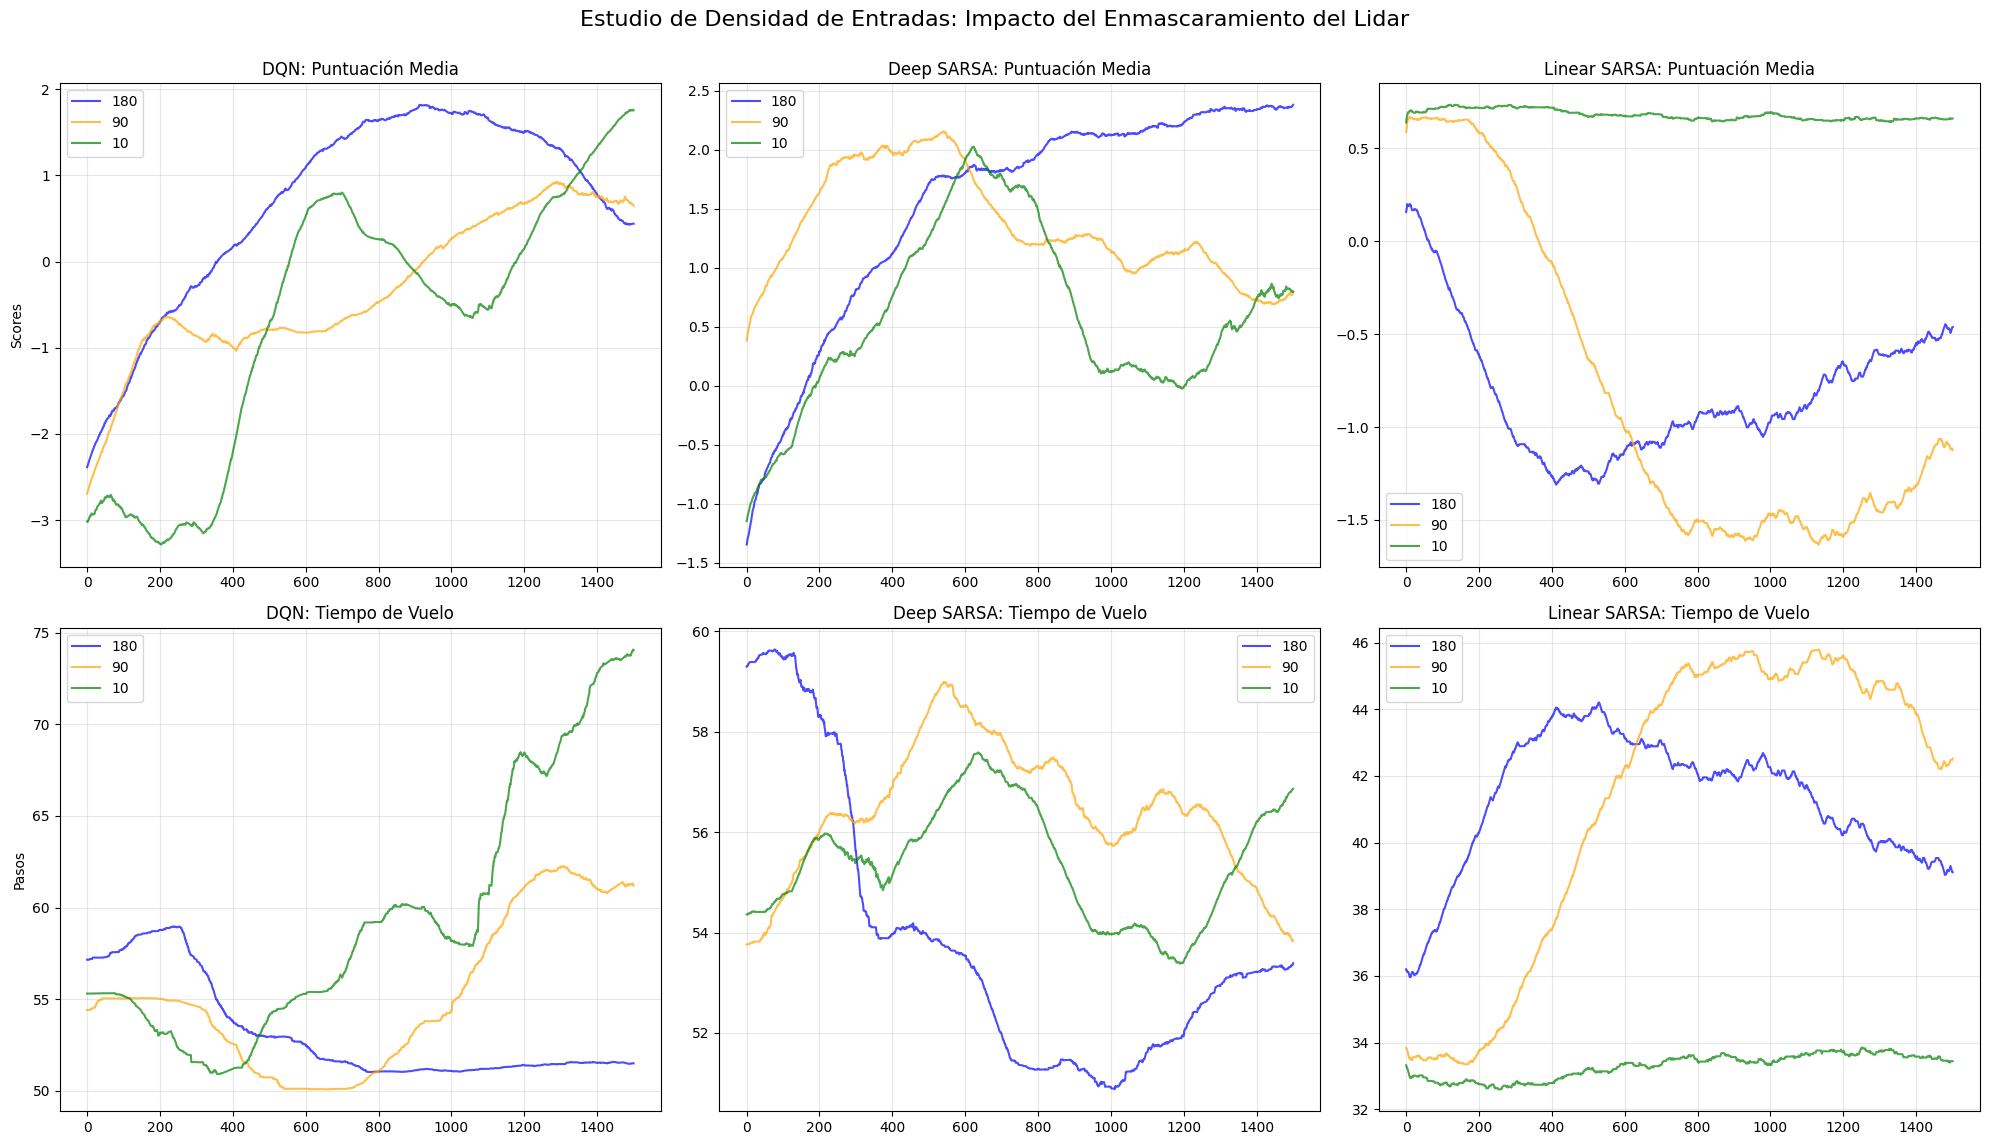

In [10]:


# Configuración de 3 columnas (DQN, Deep SARSA, Linear SARSA)
fig, axs = plt.subplots(2, 3, figsize=(20, 12)) # 2 rows (Score & Flight), 3 columns (Agents)
fig.suptitle('Estudio de Densidad de Entradas: Impacto del Enmascaramiento del Lidar', fontsize=16)

# Mapa de configuración de rayos a etiquetas y colores
ray_configs = [180, 90, 10]
colors = {180: 'blue', 90: 'orange', 10: 'green'}
labels = {180: '180', 90: '90', 10: '10'}

models = [
    ("DQN", results_rays_dqn),
    ("Deep SARSA", results_rays_deepsarsa),
    ("Linear SARSA", results_rays_linearsarsa)
]

for col_idx, (model_name, results_dict) in enumerate(models):
    ax_score = axs[0, col_idx]
    ax_flight = axs[1, col_idx]
    
    for r in ray_configs:
        if r in results_dict:
            data = results_dict[r]
            # Moving average helper
            ma_scores = moving_average(data['scores'], window_size=500)
            ma_flights = moving_average(data['flights'], window_size=500)
            
            ax_score.plot(ma_scores, label=labels[r], color=colors[r], alpha=0.7)
            ax_flight.plot(ma_flights, label=labels[r], color=colors[r], alpha=0.7)
            
    ax_score.set_title(f'{model_name}: Puntuación Media')
    ax_score.set_ylabel('Scores' if col_idx == 0 else '')
    ax_score.legend()
    ax_score.grid(True, alpha=0.3)
    
    ax_flight.set_title(f'{model_name}: Tiempo de Vuelo')
    ax_flight.set_ylabel('Pasos' if col_idx == 0 else '')
    ax_flight.legend()
    ax_flight.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## 4. Experimentación: Impacto del Learning rate

In [11]:
env = make_env(seed=SEED)
env.observation_space, env.observation_space.low,  env.observation_space.high

(Box(0.0, 1.0, (180,), float64),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
     

In [12]:
# ----------------- EJECUCIÓN EXPERIMENTO 1: Gamma -----------------
lrs = [0.001, 0.01, 0.1]
episodes = N_EPISODES 

results_dqn = {}
results_deepsarsa = {}
results_linearsarsa = {}

agents_dqn_gamma = {}
agents_deepsarsa_gamma = {}
agents_linearsarsa_gamma = {}
num_rays = 180 # Para mantener consistencia con el experimento de rayos, usamos 180 rayos en este experimento de gamma
print("=== INICIANDO EXPERIMENTO 1: Learning Rate===")
for lr in lrs:
    # 1. DQN
    dqn_ag, dqn_s, dqn_f = train_agent_masked(DQNAgent,name=f"DQN_lr_{lr}", episodes=episodes, lr=lr, num_rays=num_rays, gamma=0.999)
    results_dqn[lr] = {'scores': dqn_s, 'flights': dqn_f}
    agents_dqn_gamma[lr] = dqn_ag 
    create_experiment_media(dqn_ag, f"gifs/exp1_dqn_gamma_{lr}",num_rays=num_rays)

    # 2. Deep SARSA (Nuevo)
    ds_ag, ds_s, ds_f = train_agent_masked(DeepSARSAAgent, name=f"DeepSARSA_lr_{lr}", episodes=episodes, lr=lr, num_rays=num_rays, gamma=0.999)
    results_deepsarsa[lr] = {'scores': ds_s, 'flights': ds_f}
    agents_deepsarsa_gamma[lr] = ds_ag
    create_experiment_media(ds_ag, f"gifs/exp1_deepsarsa_gamma_{lr}", num_rays=num_rays)

    # 3. Linear SARSA (Original SARSA SG)
    ls_ag, ls_s, ls_f = train_agent_masked(LinearSARSAAgent, name=f"LinearSARSA_lr_{lr}", episodes=episodes, lr=lr, num_rays=num_rays, gamma=0.999)
    results_linearsarsa[lr] = {'scores': ls_s, 'flights': ls_f}
    agents_linearsarsa_gamma[lr] = ls_ag 
    create_experiment_media(ls_ag, f"gifs/exp1_linearsarsa_gamma_{lr}", num_rays=num_rays)

=== INICIANDO EXPERIMENTO 1: Learning Rate===
--- Iniciando: DQN_lr_0.001 | Rayos: 180 ---


Entrenando DQN_lr_0.001: 100%|██████████| 2000/2000 [03:32<00:00,  9.42it/s]


--- Iniciando: DeepSARSA_lr_0.001 | Rayos: 180 ---


Entrenando DeepSARSA_lr_0.001: 100%|██████████| 2000/2000 [03:34<00:00,  9.31it/s]


--- Iniciando: LinearSARSA_lr_0.001 | Rayos: 180 ---


...

Entrenando DQN_lr_0.1: 100%|██████████| 2000/2000 [02:56<00:00, 11.35it/s]


--- Iniciando: DeepSARSA_lr_0.1 | Rayos: 180 ---


Entrenando DeepSARSA_lr_0.1: 100%|██████████| 2000/2000 [03:04<00:00, 10.83it/s]


--- Iniciando: LinearSARSA_lr_0.1 | Rayos: 180 ---


Entrenando LinearSARSA_lr_0.1:  53%|█████▎    | 1060/2000 [01:07<00:53, 17.57it/s]C:\Users\AntonioLuisTorres\AppData\Local\Temp\ipykernel_19856\2110963752.py:277: RuntimeWarning: overflow encountered in dot
  q_values = np.dot(self.w, features)
Entrenando LinearSARSA_lr_0.1:  53%|█████▎    | 1062/2000 [01:07<00:54, 17.09it/s]C:\Users\AntonioLuisTorres\AppData\Local\Temp\ipykernel_19856\2110963752.py:268: RuntimeWarning: overflow encountered in dot
  return np.dot(self.w[action], features)
C:\Users\AntonioLuisTorres\AppData\Local\Temp\ipykernel_19856\2110963752.py:325: RuntimeWarning: invalid value encountered in scalar subtract
  error = target - q_current
Entrenando LinearSARSA_lr_0.1:  53%|█████▎    | 1065/2000 [01:07<00:51, 18.08it/s]C:\Users\AntonioLuisTorres\AppData\Local\Temp\ipykernel_19856\2110963752.py:311: RuntimeWarning: overflow encountered in dot
  q_current = np.dot(self.w[a_tau], features_tau)
Entrenando LinearSARSA_lr_0.1: 100%|██████████| 2000/2000 [01:56<00:00, 17.20i

## 5. Visualización de los Resultados

Analizamos en profundidad las 3 variables registradas para cada valor de gamma en ambos esquemas de aprendizaje (Off-Policy Neuronal vs On-Policy Lineal).

**Hipótesis esperada:**
- Con **Gamma 0.1** los Q-values serán minúsculos y su "Tiempo de Vuelo" será tan corto que indicará un choque frontal temprano contra los obstáculos por no estar previendo las penalizaciones.
- Con **Gamma 0.99** crecerá la estabilidad de estimación de la función de Valor (líneas de Q-max ascendentes y ricas en información), correlacionando fuertemente con un mayor de Tiempo de Vuelo.

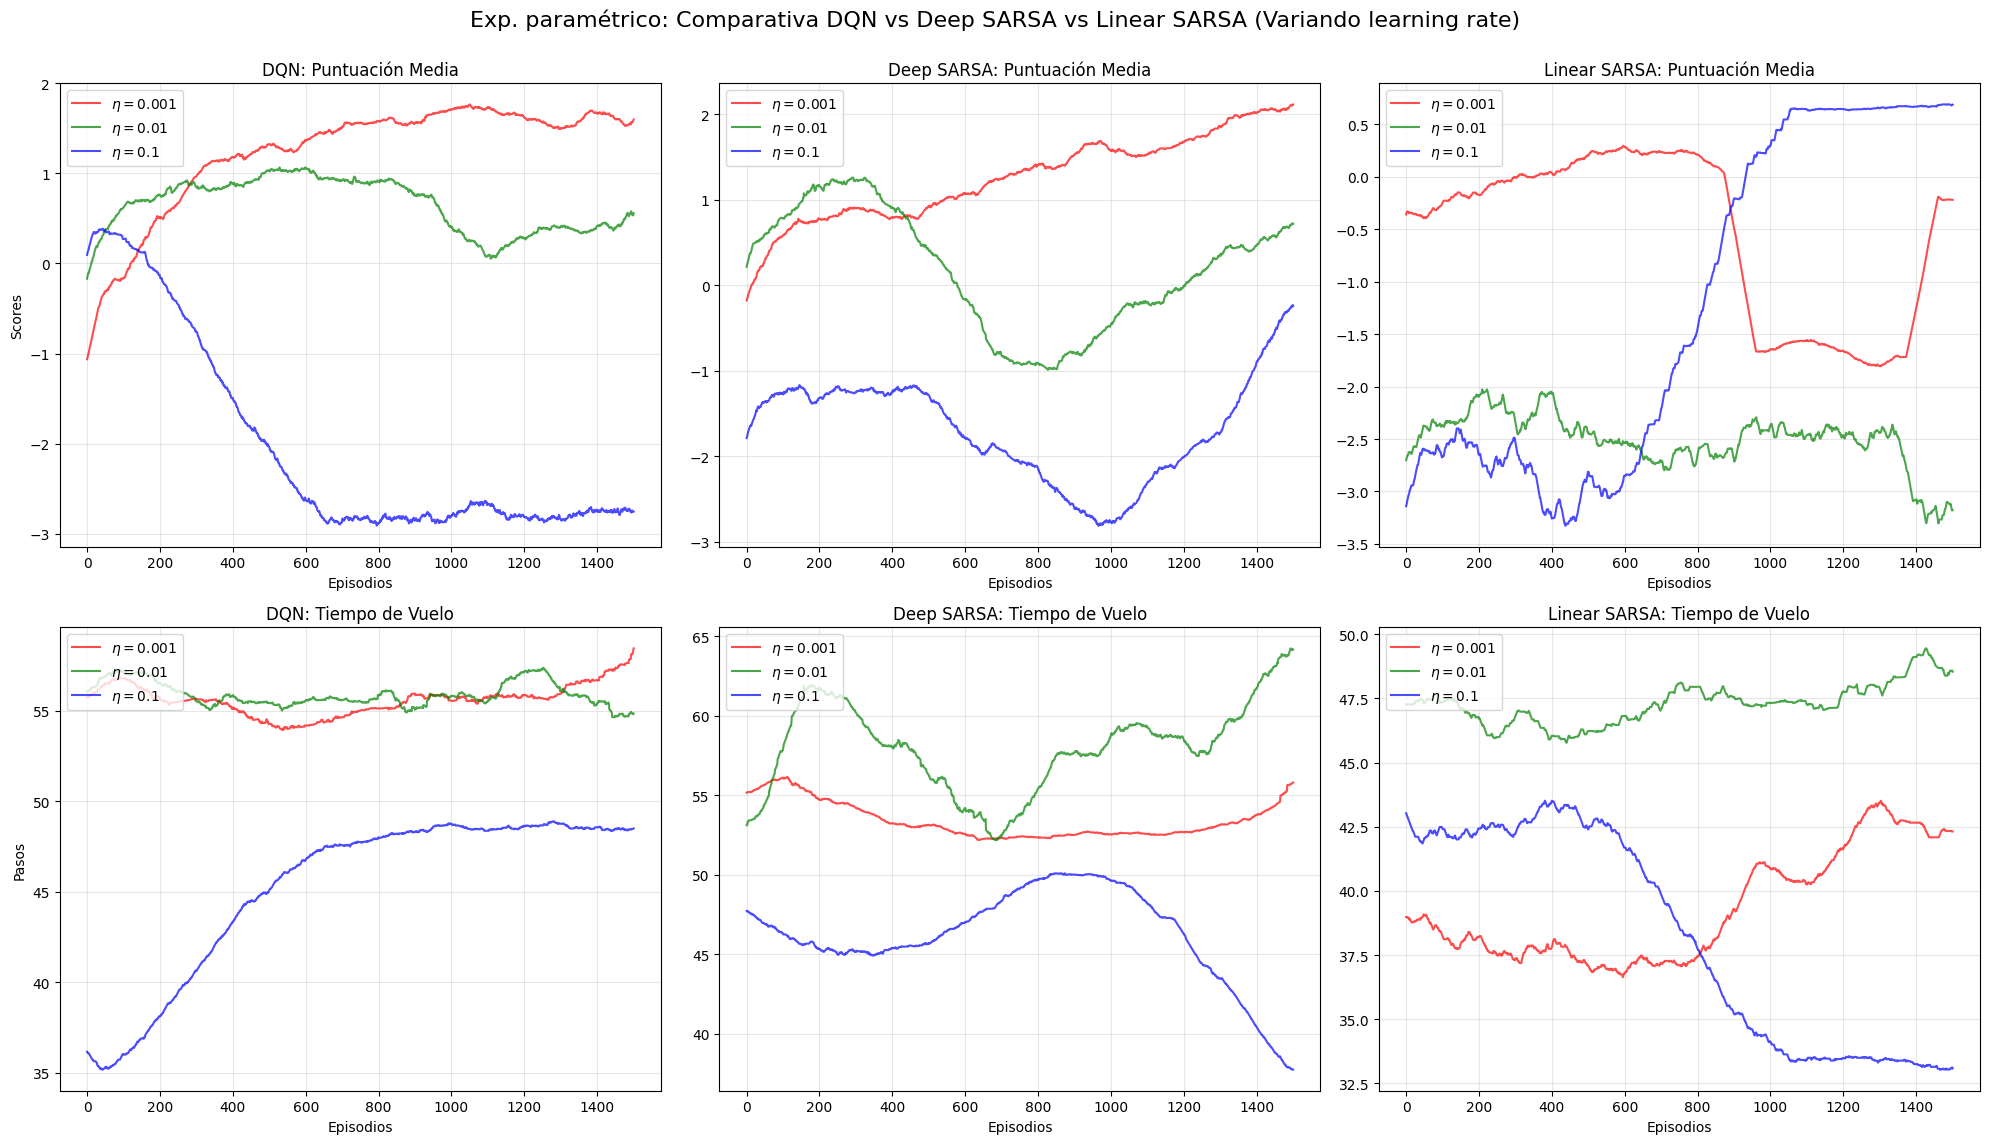

In [13]:


# Configuración de 3 columnas (DQN, Deep SARSA, Linear SARSA)
fig, axs = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Exp. paramétrico: Comparativa DQN vs Deep SARSA vs Linear SARSA (Variando learning rate)', fontsize=16)

colors = {0.001: 'red', 0.01: 'green', 0.1: 'blue'}
lrs = [0.001, 0.01, 0.1]

models = [
    ("DQN", results_dqn),
    ("Deep SARSA", results_deepsarsa),
    ("Linear SARSA", results_linearsarsa)
]

for col_idx, (model_name, results_dict) in enumerate(models):
    ax_score = axs[0, col_idx]
    ax_flight = axs[1, col_idx]
    
    for lr in lrs:
        if lr in results_dict:
            data = results_dict[lr]
            ax_score.plot(moving_average(data['scores'], window_size=500), label=f'$\eta={lr}$', color=colors[lr], alpha=0.7)
            ax_flight.plot(moving_average(data['flights'], window_size=500), label=f'$\eta={lr}$', color=colors[lr], alpha=0.7)
    
    ax_score.set_title(f'{model_name}: Puntuación Media')
    ax_score.set_ylabel('Scores' if col_idx == 0 else '')
    
    ax_flight.set_title(f'{model_name}: Tiempo de Vuelo')
    ax_flight.set_ylabel('Pasos' if col_idx == 0 else '')
    
    
    for ax in [ax_score, ax_flight]:
        ax.set_xlabel('Episodios')
        ax.legend(loc="upper left")
        ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## 7. Experimentación: Impacto de la Arquitectura de Red en DQN

Ahora que hemos comprobado el efecto del Factor de Descuento sobre ambos algoritmos, nos limitaremos a **DQN** ($\gamma=0.99$) para evaluar un hiperparámetro exclusivo del Aprendizaje Profundo: la topología de la Red Neuronal (DQN Network).

El espacio físico cuenta con $180$ distancias continuas. Queremos probar si existe **overfitting** (al usar redes demasiado amplias y profundas para 180 inputs) o un posible **underfitting** (redes que no capturen la política). Probaremos las siguientes arquitecturas de red densa (indicadas en *capas* $\times$ *nodos por capa*):

- **1x64**: $(180 \rightarrow 64 \rightarrow 2)$
- **3x64**: $(180 \rightarrow 64 \rightarrow 64 \rightarrow 64 \rightarrow 2)$
- **5x64**: $(180 \rightarrow 64 \rightarrow \text{...} \rightarrow 64 \rightarrow 2)$
- **1x512**: $(180 \rightarrow 512 \rightarrow 2)$ - *Wide Network*
- **3x128**: $(180 \rightarrow 128 \rightarrow 128 \rightarrow 128 \rightarrow 2)$ - *Estructura "Diamond"*
- **5x256**: $(180 \rightarrow 256 \rightarrow \text{...} \rightarrow 256 \rightarrow 2)$ - *Deep & Wide (Riesgo de colapso de gradiente en pocos episodios)*

In [ ]:
# ----------------- EJECUCIÓN EXPERIMENTO 3: Topología DQN y Deep SARSA -----------------
architectures = [
    (1, 64),
    (3, 64),
    (5, 64),
    (1, 512),
    (3, 256),
    (5, 256)
]

episodes_arch = N_EPISODES # 2000
results_arch_dqn = {}
results_arch_deepsarsa = {}

agents_dqn_arch = {}
agents_deepsarsa_arch = {}

print("=== INICIANDO EXPERIMENTO 3: ESTUDIO DE TOPOLOGÍAS (DQN vs Deep SARSA) ===")

for layers, hidden_dim in architectures:
    arch_name = f"{layers}x{hidden_dim}"
    print(f"\n--- Probando Arquitectura: {arch_name} ---")
    
    # 1. DQN con esta arquitectura
    name_dqn = f"DQN_{arch_name}"
    agent_d, scores_d, flights_d = train_agent_masked(
        DQNAgent, name_dqn, episodes=episodes_arch, gamma=0.99, hidden_dim=hidden_dim, num_layers=layers
    )
    results_arch_dqn[arch_name] = {'scores': scores_d, 'flights': flights_d}
    agents_dqn_arch[arch_name] = agent_d
    
    # 2. Deep SARSA con esta arquitectura
    name_ds = f"DS_{arch_name}"
    agent_ds, scores_ds, flights_ds = train_agent_masked(
        DeepSARSAAgent, name_ds, episodes=episodes_arch, gamma=0.99, hidden_dim=hidden_dim, num_layers=layers
    )
    results_arch_deepsarsa[arch_name] = {'scores': scores_ds, 'flights': flights_ds}
    agents_deepsarsa_arch[arch_name] = agent_ds

print("\nExperimento 3 Completado.")

=== INICIANDO EXPERIMENTO 3: ESTUDIO DE TOPOLOGÍAS (DQN vs Deep SARSA) ===

--- Probando Arquitectura: 1x64 ---
--- Iniciando: DQN_1x64 | Rayos: 180 ---


Entrenando DQN_1x64:  17%|█▋        | 335/2000 [00:29<02:24, 11.54it/s]

### 7.1. Visualización del Impacto Arquitectónico en DQN

In [ ]:
# Comparativa de Arquitecturas: DQN vs Deep SARSA
fig, axs = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Experimento 3: Comparación de Topologías (DQN vs Deep SARSA)', fontsize=16)

# Definimos el orden de las gráficas para que coincida con la lista de arquitecturas
# Row 0: Variando profundidad con anchura 64
# Row 1: Otras variantes (ancha, profunda y ancha)
plot_mapping = {
    "1x64": (0, 0), "3x64": (0, 1), "5x64": (0, 2),
    "1x512": (1, 0), "3x256": (1, 1), "5x256": (1, 2)
}

for arch_name, (row, col) in plot_mapping.items():
    ax = axs[row, col]
    
    # DQN Data
    if arch_name in results_arch_dqn:
        data_d = results_arch_dqn[arch_name]
        ax.plot(moving_average(data_d['scores'], window_size=500), label='DQN', color='blue', alpha=0.7)
        
    # Deep SARSA Data
    if arch_name in results_arch_deepsarsa:
        data_ds = results_arch_deepsarsa[arch_name]
        ax.plot(moving_average(data_ds['scores'], window_size=500), label='Deep SARSA', color='orange', alpha=0.7)
        
    ax.set_title(f'Arquitectura: {arch_name}')
    ax.set_ylabel('Score Promedio')
    ax.set_xlabel('Episodios')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [ ]:
# ----------------- EJECUCIÓN EXPERIMENTO 4: IMPACTO DE N-PASOS EN DQN, DEEP SARSA Y LINEAR SARSA -----------------
n_steps_list = [1, 10, 20]
episodes_nstep = N_EPISODES

results_nstep_dqn = {}
results_nstep_deepsarsa = {} 
results_nstep_linearsarsa = {}

print("=== INICIANDO EXPERIMENTO 4: IMPACTO DEL HORIZONTE TEMPORAL (N-STEPS) ===")
print("Nota: Este experimento evalúa si mirar N pasos en el futuro mejora la estabilidad de la propagación del valor.")

def train_agent_nstep_wrapper(agent_class, name, episodes, n_steps):
    # Wrapper simple que instancia correctamente pasando n_steps
    env = make_env(seed=SEED)
    # Usamos 180 rayos por defecto
    
    # Instanciación
    if agent_class == LinearSARSAAgent:
       agent = agent_class(180, action_dim, lr=1e-3, gamma=0.99, n_steps=n_steps)
    else:
       agent = agent_class(180, action_dim, lr=1e-3, gamma=0.99, n_steps=n_steps) # Defaults para DQN/DeepSARSA
       
    scores = []
    flight_times = []
    
    for i in tqdm(range(episodes), desc=f"{name}"):
        obs, _ = env.reset(seed=SEED)
        done = False
        score = 0
        steps_cnt = 0
        while not done:
            steps_cnt += 1
            action = agent.get_action(obs)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            agent.update(obs, action, next_obs, reward, terminated, truncated, {})
            done = terminated or truncated
            obs = next_obs
            score += reward
        scores.append(score)
        flight_times.append(steps_cnt)
    env.close()
    return scores, flight_times

# Re-ejecución del bucle con el wrapper correcto
for n in n_steps_list:
    # 1. DQN
    s, f = train_agent_nstep_wrapper(DQNAgent, f"DQN (N={n})", episodes_nstep, n)
    results_nstep_dqn[n] = {'scores': s, 'flights': f}
    
    # 2. Deep SARSA
    s, f = train_agent_nstep_wrapper(DeepSARSAAgent, f"DeepSARSA (N={n})", episodes_nstep, n)
    results_nstep_deepsarsa[n] = {'scores': s, 'flights': f}
    
    # 3. Linear SARSA
    s, f = train_agent_nstep_wrapper(LinearSARSAAgent, f"LinearSARSA (N={n})", episodes_nstep, n)
    results_nstep_linearsarsa[n] = {'scores': s, 'flights': f}



In [ ]:

# --- Visualización Experimento 4 ---
fig, axs = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Experimento 4: Impacto de N-Steps en Algoritmos Continuos', fontsize=16)

# Mapa de colores para N
colors_n = {1: 'blue', 10: 'orange', 20: 'green'}

models_nstep = [
    ("DQN", results_nstep_dqn),
    ("Deep SARSA", results_nstep_deepsarsa),
    ("Linear SARSA", results_nstep_linearsarsa)
]

for col_idx, (model_name, results_dict) in enumerate(models_nstep):
    ax_score = axs[0, col_idx]
    ax_flight = axs[1, col_idx]
    
    for n in n_steps_list:
        if n in results_dict:
            data = results_dict[n]
            ax_score.plot(moving_average(data['scores'], window_size=500), label=f'N={n}', color=colors_n[n], alpha=0.7)
            ax_flight.plot(moving_average(data['flights'], window_size=500), label=f'N={n}', color=colors_n[n], alpha=0.7)
            
    ax_score.set_title(f'{model_name}: Score')
    ax_score.set_ylabel('Score' if col_idx==0 else '')
    ax_score.legend()
    ax_score.grid(True, alpha=0.3)
    
    ax_flight.set_title(f'{model_name}: Vuelo')
    ax_flight.set_ylabel('Pasos' if col_idx==0 else '')
    ax_flight.legend()
    ax_flight.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [ ]:
# ----------------- EJECUCIÓN EXPERIMENTO 5: IMPACTO DE LA CONCIENCIA CINEMÁTICA (FRAME STACKING) -----------------
# Variables del experimento: ¿Mejora la supervivencia si el agente "ve el movimiento" (vectorizando t, t-1, t-2)?
stack_configs = [1, 3, 5] # Probamos 1 frame (sin memoria) vs 3 frames (con memoria cinemática)
episodes_stack = N_EPISODES # Usaremos el mismo nº de episodios definido al inicio.

results_stack_dqn = {}
results_stack_deepsarsa = {} 
results_stack_linearsarsa = {}

print("=== INICIANDO EXPERIMENTO 5: CONCIENCIA CINEMÁTICA (FRAME STACKING) ===")
print("Nota: Apilar frames permite a la red deducir la velocidad del pájaro y de las tuberías rompiendo el problema POMDP parcial.")

def train_agent_stacked_wrapper(agent_class, name, episodes, stack_k):
    # Usamos wrapper especial de stacking
    env = make_env_stacked(seed=SEED, k=stack_k, num_rays=180)
    input_dim = env.observation_space.shape[0] # Esto será k * 180
    action_dim = env.action_space.n
    
    if agent_class == LinearSARSAAgent:
       agent = agent_class(input_dim, action_dim, lr=1e-3, gamma=0.99, n_steps=3) # n_step fijo para este exp
    else:
       agent = agent_class(input_dim, action_dim, lr=1e-3, gamma=0.99, n_steps=3)
       
    scores = []
    flight_times = []
    
    for i in tqdm(range(episodes), desc=f"{name}"):
        obs, _ = env.reset(seed=SEED + i) 
        done = False
        score = 0
        steps_cnt = 0
        while not done:
            steps_cnt += 1
            action = agent.get_action(obs)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            agent.update(obs, action, next_obs, reward, terminated, truncated, {})
            done = terminated or truncated
            obs = next_obs
            score += reward
        scores.append(score)
        flight_times.append(steps_cnt)
    env.close()
    return agent, scores, flight_times

for k in stack_configs:
    k_str = f"k{k}"
    print(f"\n--- Probando Stack = {k} (Input dim: {180*k}) ---")
    
    # 1. DQN con Stack
    agent_d, s_d, f_d = train_agent_stacked_wrapper(DQNAgent, f"DQN (Stack={k})", episodes_stack, k)
    results_stack_dqn[k] = {'scores': s_d, 'flights': f_d}
    
    # 2. Deep SARSA con Stack
    agent_ds, s_ds, f_ds = train_agent_stacked_wrapper(DeepSARSAAgent, f"Deep SARSA (Stack={k})", episodes_stack, k)
    results_stack_deepsarsa[k] = {'scores': s_ds, 'flights': f_ds}
    
    # 3. Linear SARSA con Stack
    agent_ls, s_ls, f_ls = train_agent_stacked_wrapper(LinearSARSAAgent, f"Linear SARSA (Stack={k})", episodes_stack, k)
    results_stack_linearsarsa[k] = {'scores': s_ls, 'flights': f_ls}


In [ ]:

# --- Visualización Experimento 5 ---
fig, axs = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Experimento 5: Impacto del Frame Stacking (1 Frame vs 3 Frames)', fontsize=16)

colors_stack = {1: 'gray', 3: 'm', 5:'orange'}

models_stack = [
    ("DQN", results_stack_dqn),
    ("Deep SARSA", results_stack_deepsarsa),
    ("Linear SARSA", results_stack_linearsarsa)
]

for col_idx, (model_name, results_dict) in enumerate(models_stack):
    ax_score = axs[0, col_idx]
    ax_flight = axs[1, col_idx]
    
    for k in stack_configs:
        if k in results_dict:
            data = results_dict[k]
            ax_score.plot(moving_average(data['scores'], window_size=500), label=f'Stack K={k}', color=colors_stack[k], alpha=0.8)
            ax_flight.plot(moving_average(data['flights'], window_size=500), label=f'Stack K={k}', color=colors_stack[k], alpha=0.8)
            
    ax_score.set_title(f'{model_name}: Score')
    ax_score.set_ylabel('Score' if col_idx==0 else '')
    ax_score.legend()
    ax_score.grid(True, alpha=0.3)
    
    ax_flight.set_title(f'{model_name}: Tiempo de Vuelo')
    ax_flight.set_ylabel('Pasos' if col_idx==0 else '')
    ax_flight.legend()
    ax_flight.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Resultados del Experimento 5: Impacto de la Conciencia Cinemática (Frame Stacking)

En este experimento evaluamos el efecto de proporcionar información de estados pasados al agente (K=3) en lugar de utilizar solo el estado actual (K=1). 

**Qué hemos medido:**
- **Scores** (Columnas 1-3, Fila 1): Comparamos el "score" total logrado en los últimos episodios, indicando un aprendizaje más robusto general cuando K=3 en agentes no lineales.
- **Flight Time / Pasos** (Columnas 1-3, Fila 2): Medimos directamente el tiempo máximo de supervivencia, un factor importante en el comportamiento de "evitación de obstáculos".

**Conclusiones Teóricas Esperadas de las Gráficas:**
1. **DQN / Deep SARSA**: Deberían mostrar una clara mejora de "flight time" en episodios tardíos al utilizar Frame Stacking K=3, porque las redes neuronales pueden aprender a deducir la velocidad (derivada espacial de las tuberías) al correlacionar el rayo lidar $X_t$ con $X_{t-1}$. 
2. **Linear SARSA**: Podría saturarse o sufrir debido al sobre-proporcionamiento de variables (ruido dimensional al triplicar features sin interacciones no lineales profundas que las exploten).
3. En general, con *K=3*, el agente tiene capacidad de predecir la aproximación vertical/horizontal de un obstáculo antes de estrellarse repentinamente, mitigando los "Saltos Mortales" imprevistos debidos al POMDP (Proceso de Decisión de Markov Parcialmente Observable).